# Drift Sentinel: EDA & Frozen Holdout

Goal: understand the fraud dataset well enough to justify **where** we carve the frozen holdout, aka the fixed ruler every model version is scored against.

In [14]:
import pandas as pd

df = pd.read_csv("../data/creditcard.csv")

# Structure scan: dtypes + non-null counts. The non-null counts confirm there are
# zero missing values, which is worth knowing before any modeling.
print("--- Column Info & Data Types ---")
df.info()

# The columns as a clean list
print("\n--- All Column Names ---")
print(df.columns.tolist())

# Target class distribution (0 = Legit, 1 = Fraud)
print("\n--- Target Class Counts ---")
print(df["Class"].value_counts())

print("\n--- Target Class Percentages ---")
print(df["Class"].value_counts(normalize=True) * 100)

--- Column Info & Data Types ---
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  f

## Class balance: why imbalance breaks naive models and naive metrics

The split is **99.83% legit to 0.17% fraud** (about 578 legit transactions for every fraud). That single ratio causes two separate failures, and they are worth keeping distinct.

**1. It biases the model toward "always legit."** During training the loss is dominated by the majority class, so the cheapest way for the model to lower its error is to predict "legit" for almost everything. Left unchecked, an imbalanced dataset produces a model that quietly gives up on the rare class it was actually built to catch. (We counter this on the training side with class weighting and threshold tuning in Phase 2.)

**2. It makes accuracy a liar.** A model that predicts "never fraud" scores ~99.8% accuracy while catching zero fraud. Accuracy rewards the exact failure mode imbalance encourages, so it cannot be trusted here.

The fix for the second problem is to score the model only on how it handles the rare class. That is what precision, recall, F1, and PR-AUC do, and it is why promotion is gated on those and **never on accuracy.**

In [ ]:
counts = df["Class"].value_counts()
# Class is 0/1, so its mean IS the fraction of frauds. Averaging a boolean or 0/1
# column to get a rate is a trick worth pocketing; it recurs all over this project.
fraud_rate = df["Class"].mean()
counts, f"fraud_rate: {fraud_rate:.3%}"

## The metrics we gate on, and why

At 0.173% fraud, any metric that rewards a model for ignoring the rare class is useless. The fix is to score the model on how it handles the frauds specifically. Every prediction is really an alert decision, which gives four outcomes:

|                     | Model says FRAUD (alert fires) | Model says legit (silent) |
|---------------------|--------------------------------|---------------------------|
| **Actually fraud**  | true positive (caught it)      | false negative (missed it) |
| **Actually legit**  | false positive (false alarm)   | true negative (correctly quiet) |

Every metric below is just a ratio over that table.

**Precision** = true positives / (true positives + false positives). Of everything we flagged as fraud, how much really was fraud. Low precision means alert fatigue and blocked legitimate customers.

**Recall** = true positives / (true positives + false negatives). Of all the real frauds, how many we caught. Low recall means fraud slips through, and for this problem that is the expensive error: a missed fraud is money out the door, often unrecoverable.

**F1** = the harmonic mean of precision and recall. One number that stays low unless *both* are decent, so it refuses to reward the two cheating extremes (flag everything, or flag nothing).

### Why PR-AUC is the metric we gate on

PR-AUC is the area under the precision-recall curve. A model does not output a hard label, it outputs a fraud *probability*, and the decision threshold we pick trades precision against recall. PR-AUC integrates that tradeoff across every possible threshold into one number, so it measures how well the model *ranks* frauds above legit transactions rather than grading one arbitrary cutoff.

That property is exactly what an imbalanced problem needs, for two reasons:

- **It only involves the rare class.** Precision and recall are both computed from true positives, false positives, and false negatives. None of them use the huge true-negative count, so a flood of easy legit transactions cannot inflate the score. A model has to actually rank frauds well to score well.
- **It is honest where ROC-AUC flatters.** ROC-AUC uses the true-negative count, which is enormous here, so it can look impressive (0.95+) even when precision at useful recall is poor. PR-AUC does not get that free credit, so on rare-event problems it is the stricter, more informative ruler.

To be precise about what PR-AUC does and does not fix: it solves *measurement* under imbalance. It does not fix the model's bias toward the majority class; that is handled during training with class weighting and threshold tuning.

### Why not accuracy

The "always predict legit" model, on our real numbers:

| Metric | Value | Reason |
|--------|-------|--------|
| Accuracy | 99.83% | It is right on all 284,315 legit rows |
| Recall | 0% | It catches none of the 492 frauds |
| Precision | undefined | It never fires an alert |

Accuracy rewards doing nothing. Recall, precision, and PR-AUC cannot be fooled that way because they only look at the frauds.

**The decision.** `metrics.json` reports precision, recall, F1, and PR-AUC. Promotion is gated on **PR-AUC** (threshold-independent and imbalance-honest), and we watch **recall** closely because the costly error here is the missed fraud. Accuracy is never a gate.

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# The do-nothing baseline: predict "legit" (0) for every single transaction.
# This is the model the imbalance makes look good, and the one we must beat.
y_true = df["Class"]
y_pred = pd.Series(0, index=df.index)

# zero_division=0 tells sklearn to report 0 (not raise) when a metric is undefined.
# Precision is undefined here because the model never predicts fraud, so there are
# no positive predictions to divide by; sklearn returns 0 by convention.
print("Always-predict-legit baseline")
print(f"  accuracy : {accuracy_score(y_true, y_pred):.4%}")
print(f"  precision: {precision_score(y_true, y_pred, zero_division=0):.4f}  (undefined: no positive predictions)")
print(f"  recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}  (catches 0 of 492 frauds)")
print(f"  f1       : {f1_score(y_true, y_pred, zero_division=0):.4f}")

Always-predict-legit baseline
  accuracy : 99.8273%
  precision: 0.0000  (undefined: no positive predictions)
  recall   : 0.0000  (catches 0 of 492 frauds)
  f1       : 0.0000


## Where do the frauds live over time?

The holdout must be an early, fixed time slice. That's only safe if the early slice actually contains enough fraud to score a model on. Let's check:

In [8]:
df["time_bucket"] = pd.qcut(df["Time"], 10, labels=False)
by_time = df.groupby("time_bucket").agg(
    rows=("Class", "size"),
    frauds=("Class", "sum"),
)
by_time["fraud_%"] = (100 * by_time["frauds"] / by_time["rows"]).round(3)
by_time

,rows,frauds,fraud_%
time_bucket,,,
0,28482,93,0.327
1,28480,64,0.225
2,28483,47,0.165
3,28478,37,0.130
4,28481,28,0.098
5,28484,91,0.319
6,28480,24,0.084
7,28477,33,0.116
8,28481,53,0.186


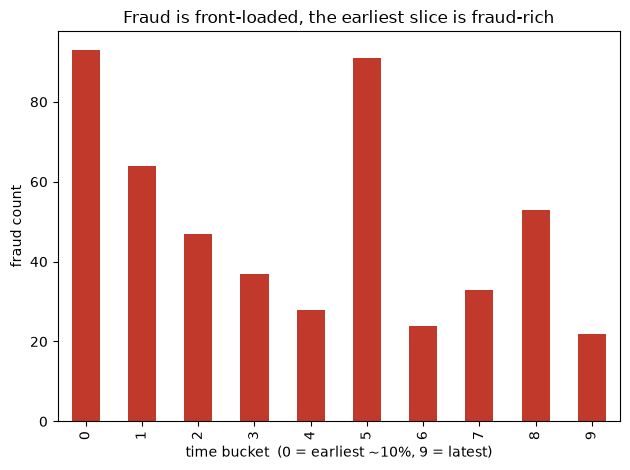

In [13]:
import matplotlib.pyplot as plt

# One bar per time bucket, drawn straight from the Series. This chart exists to
# answer one question: is the early slice fraud-rich enough to hold out? It is not
# a dashboard. Grafana (Phase 4) is where visualization polish belongs.
ax = by_time["frauds"].plot(kind="bar", color="#c0392b")
ax.set_xlabel("time bucket  (0 = earliest ~10%, 9 = latest)")
ax.set_ylabel("fraud count")
ax.set_title("Fraud is front-loaded, the earliest slice is fraud-rich")
plt.tight_layout()  # call it (with parens) so it actually rescales the figure

## Decision: the frozen holdout

The earliest time buckets are the **most** fraud-dense (bucket 0 ≈ 93 frauds), so an early holdout is well supplied with the positives we need to score models on.

**We carve the earliest 20% of transactions by `Time` as the frozen holdout:**

- ~56,962 rows and ~157 frauds, enough positives for a stable PR-AUC.
- It is the front of the timeline, so it is disjoint by construction from the training pool (middle) and the drift-replay traffic (late). No model version can ever be trained on it.
- It is written once, hashed, and the hash is committed. Every future model version is scored against this exact file: the single fixed ruler that makes champion-vs-challenger comparisons valid.